# Notebook 07 — Índices HDD y CRI sobre la ventana fenológica del arroz

Construcción y caracterización empírica de los **subyacentes climáticos** sobre los que se valoran los contratos del proyecto:

- **HDD (Heating Degree Days)** — exposición acumulada a temperatura por encima de un umbral $T^*$. Subyacente del **call HDD** (cobertura ante estrés térmico, escenario Niño).
- **CRI (Cumulative Rainfall Index)** — precipitación acumulada en la ventana. Subyacente del **put CRI** (cobertura ante déficit pluvial, escenario Niño) y del **call CRI** (cobertura ante exceso, escenario Niña).

Los índices se calculan sobre la **ventana fenológica crítica del arroz** (días 60–100 desde siembra: floración + llenado del grano), donde la sensibilidad climática del rendimiento es máxima.

## Calendario fenológico

Para cada combinación de zona arrocera y semestre se define una fecha de siembra típica y la ventana crítica resultante:

| Zona | Semestre | Siembra típica | Ventana crítica (días 60–100) |
|---|---|---|---|
| Tolima | A (principal) | 15-mar | 14-may → 22-jun |
| Tolima | B (mitaca) | 15-ago | 14-oct → 22-nov |
| Casanare | A | 15-abr | 14-jun → 23-jul |
| Casanare | B | 15-ago | 14-oct → 22-nov |


## 


> **Fuentes:**
> - Calendario de siembra: Fedearroz, *Estadísticas Arroceras — Área, producción y rendimiento por zonas*, https://fedearroz.com.co/es/fondo-nacional-del-arroz/investigaciones-economicas/estadisticas-arroceras/area-produccion-y-rendimiento/. Las fechas representativas son aproximaciones de los picos de siembra reportados por Fedearroz y el Censo Nacional Arrocero DANE-Fedearroz (2023).
> - Ciclo fenológico: Yoshida, S. (1981), *Fundamentals of Rice Crop Science*, IRRI; y Counce, P. A., Keisling, T. C., & Mitchell, A. J. (2000). A uniform, objective, and adaptive system for expressing rice development. *Crop Science*, 40(2), 436–443. https://doi.org/10.2135/cropsci2000.402436x. Confirman la ventana 60–100 días como período más sensible al estrés térmico e hídrico en variedades modernas de ~120 días.
>
> **Threshold de estrés térmico $T^* = 32 ^ \circ\text{C}$:**
> - Krishnan, P., Ramakrishnan, B., Reddy, K. R., & Reddy, V. R. (2011). High-temperature effects on rice growth, yield, and grain quality. *Advances in Agronomy*, 111, 87–206. https://doi.org/10.1016/B978-0-12-387689-8.00004-7. Establece que por encima de 32 °C durante floración la fertilidad del polen cae sustancialmente.
> - Wassmann, R. et al. (2009). Climate change affecting rice production: The physiological and agronomic basis for possible adaptation strategies. *Advances in Agronomy*, 101, 59–122. https://doi.org/10.1016/S0065-2113(08)00802-X. Cita 32 °C como umbral operativo en literatura agronómica tropical.
>
> **Nota técnica:** el modelo del notebook 02 simula `t_mean` (temperatura media diaria), no `t_max`. En zona Centro y Llanos de Colombia la `t_mean` rara vez supera 30 °C, así que **HDD sobre `t_mean` con $T^* = 32^\circ\text{C}$ se activará pocas veces** — eso refleja la realidad física, no un defecto del modelo. Se incluye **análisis de sensibilidad a $T^* \in \{28, 30, 32\}^\circ\text{C}$** para que el lector vea la respuesta del índice.

In [11]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

OUT_DIR = Path("../data/processed")
VAR_TEMP = "t_max"  

## 1. Carga de datos

In [12]:
# Trayectorias Monte Carlo del notebook 06
mc = pd.read_parquet(OUT_DIR / "mc_paths.parquet")
print(f"MC: {mc.shape[0]:,} filas | {mc['path_id'].nunique():,} paths × "
      f"{mc.groupby(['dpto','fase','path_id'], observed=True)['date'].count().iloc[0]} días "
      f"× {mc['fase'].nunique()} fases × {mc['dpto'].nunique()} dptos")
print(f"Rango simulación: {mc['date'].min().date()} → {mc['date'].max().date()}")

# Datos históricos (para diagnóstico de bias)
df_hist = pd.read_excel("../data/processed/Modelo_Completo.xlsx",
                        parse_dates=["date"]).set_index("date")
enso = pd.read_excel("../data/processed/Modelo_Completo.xlsx", sheet_name="CapaB_ENSO")
enso["date"] = pd.to_datetime(enso["date"])
enso_daily = enso.set_index("date")[["roni", "fase"]].resample("D").ffill()

hist_por_dpto = {}
for dpto in ["Tolima", "Casanare"]:
    sub = df_hist[df_hist["department"] == dpto][[VAR_TEMP, "precip"]].copy()
    sub = sub.join(enso_daily, how="left").dropna()
    hist_por_dpto[dpto] = sub

for d, s in hist_por_dpto.items():
    print(f"  Histórico {d}: {s.index.min().date()} → {s.index.max().date()}  ({len(s):,} días)")

MC: 21,900,000 filas | 10,000 paths × 365 días × 3 fases × 2 dptos
Rango simulación: 2025-12-02 → 2026-12-01
  Histórico Tolima: 2010-01-01 → 2025-12-01  (5,814 días)
  Histórico Casanare: 2010-01-01 → 2025-12-01  (5,814 días)


## 2. Calendario fenológico y resolución de ventanas

Se define el calendario con `siembra_mm_dd` y se buscan las fechas exactas dentro del rango de simulación.

In [13]:
# Calendario representativo (Fedearroz, Censo Nacional Arrocero 2023)
CALENDARIO = {
    "Tolima":   {"A": "03-15", "B": "08-15"},
    "Casanare": {"A": "04-15", "B": "08-15"},
}
DIA_INICIO_VENTANA = 60      # días desde siembra al inicio de floración
DURACION_VENTANA   = 40      # días de la ventana crítica (floración + llenado)


def resolver_ventana(siembra_mm_dd, anio, fechas_disponibles):
    """Devuelve (fecha_inicio, fecha_fin) de la ventana fenológica, o None si
    no cabe en el rango de simulación."""
    siembra = pd.Timestamp(f"{anio}-{siembra_mm_dd}")
    inicio  = siembra + pd.Timedelta(days=DIA_INICIO_VENTANA)
    fin     = siembra + pd.Timedelta(days=DIA_INICIO_VENTANA + DURACION_VENTANA - 1)
    if inicio < fechas_disponibles.min() or fin > fechas_disponibles.max():
        return None
    return inicio, fin


# Resolver ventanas para el rango de simulación
fechas_sim = pd.DatetimeIndex(sorted(mc["date"].unique()))
anios_sim  = sorted(set(fechas_sim.year))

ventanas = []
for dpto in ["Tolima", "Casanare"]:
    for sem, mm_dd in CALENDARIO[dpto].items():
        for anio in anios_sim:
            v = resolver_ventana(mm_dd, anio, fechas_sim)
            if v:
                ventanas.append({
                    "dpto": dpto, "semestre": sem,
                    "anio_siembra": anio,
                    "inicio": v[0], "fin": v[1],
                    "n_dias": (v[1] - v[0]).days + 1,
                })

ventanas_df = pd.DataFrame(ventanas)
print("Ventanas fenológicas dentro del rango de simulación:")
print(ventanas_df.to_string(index=False))

Ventanas fenológicas dentro del rango de simulación:
    dpto semestre  anio_siembra     inicio        fin  n_dias
  Tolima        A          2026 2026-05-14 2026-06-22      40
  Tolima        B          2026 2026-10-14 2026-11-22      40
Casanare        A          2026 2026-06-14 2026-07-23      40
Casanare        B          2026 2026-10-14 2026-11-22      40


## 3. Cálculo de HDD y CRI sobre las trayectorias

Para cada ventana resuelta y cada path simulado:

$$\text{HDD}(T^*) = \sum_{t \in W} \max\!\left(T^{\text{mean}}_t - T^*,\, 0\right) \qquad
\text{CRI} = \sum_{t \in W} P_t$$

El HDD se reporta para tres niveles de $T^*$ (28, 30, 32 °C) para análisis de sensibilidad. El CRI no depende de un umbral.

In [14]:
T_STAR_VALUES = [30.0, 32.0, 34.0]   # umbrales para sensibilidad
T_STAR_REF = 32                # umbral de referencia (literatura)


def calcular_indices_paths(mc_filtrado, inicio, fin, var_temp=VAR_TEMP):
    """Calcula HDD (3 umbrales) y CRI para cada path en una ventana dada.

    Parámetros
    ----------
    mc_filtrado : DataFrame con columnas [path_id, date, t_mean, precip],
                  ya filtrado a un único (dpto, fase).
    inicio, fin : pd.Timestamp de la ventana.

    Retorna
    -------
    DataFrame indexado por path_id con columnas HDD_30, HDD_32, HDD_34, CRI.
    """
    mask = (mc_filtrado["date"] >= inicio) & (mc_filtrado["date"] <= fin)
    win  = mc_filtrado.loc[mask]
    if win.empty:
        return pd.DataFrame()

    out = []
    for path_id, grupo in win.groupby("path_id"):
        t    = grupo[var_temp].values
        p    = grupo["precip"].values
        fila = {"path_id": path_id, "CRI": p.sum()}
        for ts in T_STAR_VALUES:
            fila[f"HDD_{int(ts)}"] = np.maximum(t - ts, 0).sum()
        out.append(fila)
    return pd.DataFrame(out).set_index("path_id")


def calcular_indices_historicos(df_hist_dpto, inicio_mm_dd, anios_disponibles, fase, var_temp=VAR_TEMP):
    """Calcula HDD/CRI sobre el histórico para diagnóstico de bias.

    Toma la misma ventana mes-día en cada año disponible, filtra por fase ENSO,
    y devuelve una serie de índices anuales.
    """
    out = []
    mes_ini, dia_ini = map(int, inicio_mm_dd.split("-"))
    for anio in anios_disponibles:
        inicio = pd.Timestamp(f"{anio}-{mes_ini:02d}-{dia_ini:02d}") + pd.Timedelta(days=DIA_INICIO_VENTANA)
        fin    = inicio + pd.Timedelta(days=DURACION_VENTANA - 1)
        win = df_hist_dpto.loc[inicio:fin]
        if len(win) < DURACION_VENTANA * 0.8:    # tolerancia 20% missing
            continue
        # Fase ENSO dominante en la ventana
        fase_w = win["fase"].mode().iloc[0] if not win["fase"].mode().empty else None
        if fase_w != fase:
            continue
        fila = {"anio": anio, "n_dias": len(win), "CRI": win["precip"].sum()}
        for ts in T_STAR_VALUES:
            fila[f"HDD_{int(ts)}"] = np.maximum(win[var_temp].values - ts, 0).sum()
        out.append(fila)
    return pd.DataFrame(out)

## 4. Cálculo masivo de índices sobre todas las trayectorias

In [15]:
ESCENARIOS = ["Niño", "Neutro", "Niña"]

indices_largo = []      # acumular en formato largo: una fila por (path × ventana × fase)
for _, v in ventanas_df.iterrows():
    dpto = v["dpto"]
    for fase in ESCENARIOS:
        mc_sub = mc[(mc["dpto"] == dpto) & (mc["fase"] == fase)]
        idx_df = calcular_indices_paths(mc_sub, v["inicio"], v["fin"])
        if idx_df.empty:
            continue
        idx_df = idx_df.reset_index()
        idx_df["dpto"]         = dpto
        idx_df["semestre"]     = v["semestre"]
        idx_df["fase"]         = fase
        idx_df["anio_siembra"] = v["anio_siembra"]
        idx_df["v_inicio"]     = v["inicio"]
        idx_df["v_fin"]        = v["fin"]
        indices_largo.append(idx_df)

indices = pd.concat(indices_largo, ignore_index=True)
indices["v_inicio"] = pd.to_datetime(indices["v_inicio"])
indices["v_fin"]    = pd.to_datetime(indices["v_fin"])
print(f"Tabla de índices: {indices.shape}")
print(indices.head())

Tabla de índices: (120000, 11)
   path_id         CRI     HDD_30     HDD_32    HDD_34    dpto semestre  fase  \
0        0   86.322441  42.132612   7.561260  0.805589  Tolima        A  Niño   
1        1  151.475751  54.577629  15.502113  2.532473  Tolima        A  Niño   
2        2  213.024221  28.690340   5.042703  0.000000  Tolima        A  Niño   
3        3  211.029684  41.235709  10.789549  1.458666  Tolima        A  Niño   
4        4   53.340897  40.982038   6.961575  0.000000  Tolima        A  Niño   

   anio_siembra   v_inicio      v_fin  
0          2026 2026-05-14 2026-06-22  
1          2026 2026-05-14 2026-06-22  
2          2026 2026-05-14 2026-06-22  
3          2026 2026-05-14 2026-06-22  
4          2026 2026-05-14 2026-06-22  


## 5. Estadísticos resumen y cuantiles

Media, std y cuantiles 10%, 25%, 50%, 75%, 90% para cada combinación.

In [16]:
def resumen_indices(indices, columna):
    """Tabla pivote: media, std, cuantiles por (dpto, semestre, fase)."""
    agg = (indices.groupby(["dpto", "semestre", "fase"], observed=True)[columna]
                    .agg(["mean", "std",
                          ("p10", lambda x: x.quantile(0.10)),
                          ("p25", lambda x: x.quantile(0.25)),
                          ("p50", lambda x: x.quantile(0.50)),
                          ("p75", lambda x: x.quantile(0.75)),
                          ("p90", lambda x: x.quantile(0.90))])
                    .round(2)
                    .reset_index())
    return agg


print("=" * 75)
print(f"CRI (mm) por (dpto × semestre × fase)")
print("=" * 75)
print(resumen_indices(indices, "CRI").to_string(index=False))

for ts in T_STAR_VALUES:
    print(f"\n{'='*75}")
    print(f"HDD con T* = {int(ts)} °C")
    print("=" * 75)
    print(resumen_indices(indices, f"HDD_{int(ts)}").to_string(index=False))

CRI (mm) por (dpto × semestre × fase)
    dpto semestre   fase   mean    std    p10    p25    p50    p75    p90
Casanare        A Neutro 483.42  83.39 379.36 426.00 479.78 537.21 589.77
Casanare        A   Niña 576.06 109.07 436.84 501.08 572.80 649.07 717.38
Casanare        A   Niño 580.99  83.16 476.78 523.15 579.35 634.79 688.41
Casanare        B Neutro 145.74  49.14  86.47 110.36 141.95 176.53 210.59
Casanare        B   Niña 239.09  66.14 157.46 192.54 235.41 281.71 326.13
Casanare        B   Niño 151.52  50.26  89.78 115.90 147.57 182.84 217.61
  Tolima        A Neutro 154.72  74.51  70.10 100.98 143.07 197.25 252.96
  Tolima        A   Niña 208.52  74.76 115.97 154.66 203.39 255.60 307.53
  Tolima        A   Niño 145.43  93.14  46.71  76.85 124.78 193.66 271.86
  Tolima        B Neutro 135.74  54.56  70.90  95.78 129.59 168.97 209.07
  Tolima        B   Niña 214.40  66.30 131.65 166.89 210.43 257.11 303.37
  Tolima        B   Niño 131.65  63.06  59.00  85.17 121.85 168.30 217.51


## 6. Diagnóstico de bias: simulado vs. histórico

Para cada (zona, semestre, fase) se calcula el CRI/HDD sobre el **histórico real** (mismas ventanas mes-día, mismo filtro de fase ENSO) y se compara con la **media simulada**.

Si el bias en CRI dentro de la ventana es < 20%, no aplicamos corrección. Si es mayor, reportamos un factor multiplicativo $k = \overline{\text{CRI}}_{\text{hist}} / \overline{\text{CRI}}_{\text{sim}}$ para uso posterior en el notebook 08.

In [17]:
hist_indices = []
for dpto in ["Tolima", "Casanare"]:
    for sem, mm_dd in CALENDARIO[dpto].items():
        anios_hist = sorted(set(hist_por_dpto[dpto].index.year))
        for fase in ESCENARIOS:
            df_h = calcular_indices_historicos(hist_por_dpto[dpto], mm_dd, anios_hist, fase)
            if df_h.empty:
                continue
            df_h["dpto"] = dpto; df_h["semestre"] = sem; df_h["fase"] = fase
            hist_indices.append(df_h)

hist_idx_df = pd.concat(hist_indices, ignore_index=True)
print(f"Tabla histórica: {hist_idx_df.shape}")

# Comparación simulado vs histórico (media por grupo)
comp = (indices.groupby(["dpto", "semestre", "fase"], observed=True)
                .agg(CRI_sim=("CRI", "mean"),
                     HDD32_sim=("HDD_32", "mean"))
                .reset_index())
comp_h = (hist_idx_df.groupby(["dpto", "semestre", "fase"])
                     .agg(CRI_hist=("CRI", "mean"),
                          HDD32_hist=("HDD_32", "mean"),
                          n_anios_hist=("anio", "count"))
                     .reset_index())
comparativo = comp.merge(comp_h, on=["dpto", "semestre", "fase"], how="left")
comparativo["bias_CRI_pct"]   = 100 * (comparativo["CRI_sim"] - comparativo["CRI_hist"]) / comparativo["CRI_hist"]
comparativo["shift_CRI"] = comparativo["CRI_hist"] - comparativo["CRI_sim"]      # corrección aditiva (mm) 
comparativo["k_correccion"]   = comparativo["CRI_hist"] / comparativo["CRI_sim"]

print("\nDiagnóstico de bias en CRI (ventana fenológica):\n")
print(comparativo[["dpto", "semestre", "fase", "n_anios_hist",
                   "CRI_hist", "CRI_sim", "bias_CRI_pct", "shift_CRI", "k_correccion",
                   "HDD32_hist", "HDD32_sim"]].round(2).to_string(index=False))

# Veredicto
bias_max = comparativo["bias_CRI_pct"].abs().max()
print(f"\nBias máximo absoluto en CRI: {bias_max:.1f}%")
if bias_max < 20:
    print("→ Bias aceptable (<20%): NO se aplica corrección.")
else:
    print(f"→ Bias > 20%: se exporta factor de corrección k por (dpto, semestre, fase)")
    print(f"   para aplicarse en el notebook 08 antes de la valoración.")

Tabla histórica: (64, 9)

Diagnóstico de bias en CRI (ventana fenológica):

    dpto semestre   fase  n_anios_hist  CRI_hist  CRI_sim  bias_CRI_pct  shift_CRI  k_correccion  HDD32_hist  HDD32_sim
Casanare        A Neutro            12    475.26   483.42          1.72      -8.16          0.98        0.02       1.10
Casanare        A   Niña             2    524.52   576.06          9.83     -51.55          0.91        0.00       1.09
Casanare        A   Niño             2    575.56   580.99          0.94      -5.43          0.99        0.43       2.72
Casanare        B Neutro             3    279.76   145.74        -47.90     134.02          1.92        8.22      10.29
Casanare        B   Niña             8    310.88   239.09        -23.09      71.79          1.30        2.62       6.36
Casanare        B   Niño             5    211.29   151.52        -28.29      59.77          1.39        4.54      10.60
  Tolima        A Neutro            11    198.16   154.72        -21.92      43.44  

## 7. Visualización de las distribuciones de índices

Histogramas comparativos por fase ENSO (Niño / Neutro / Niña) para CRI y HDD en cada ventana.

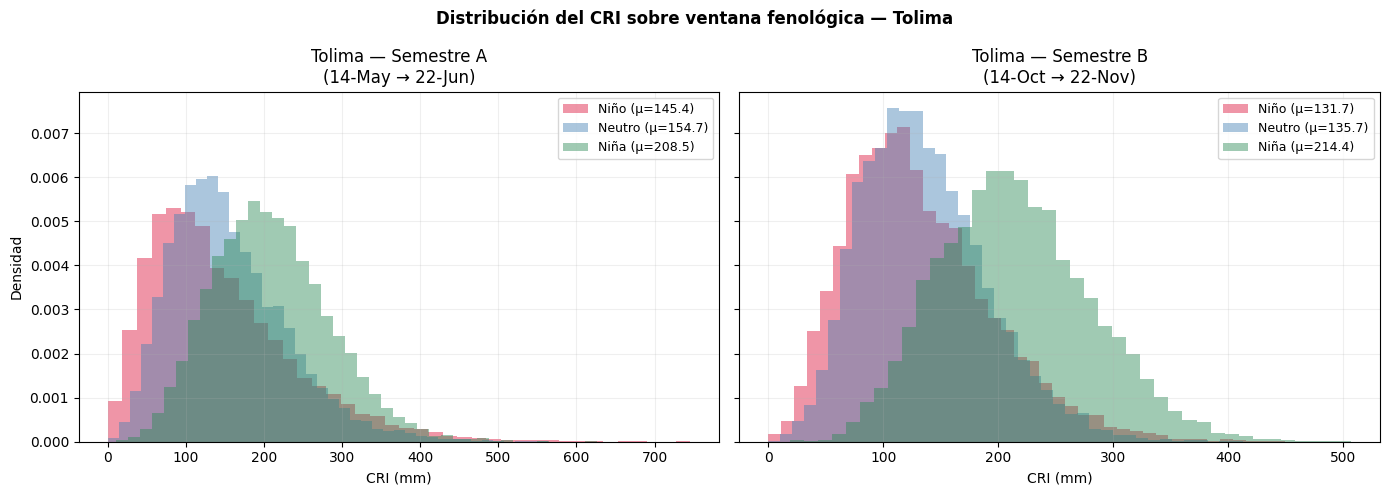

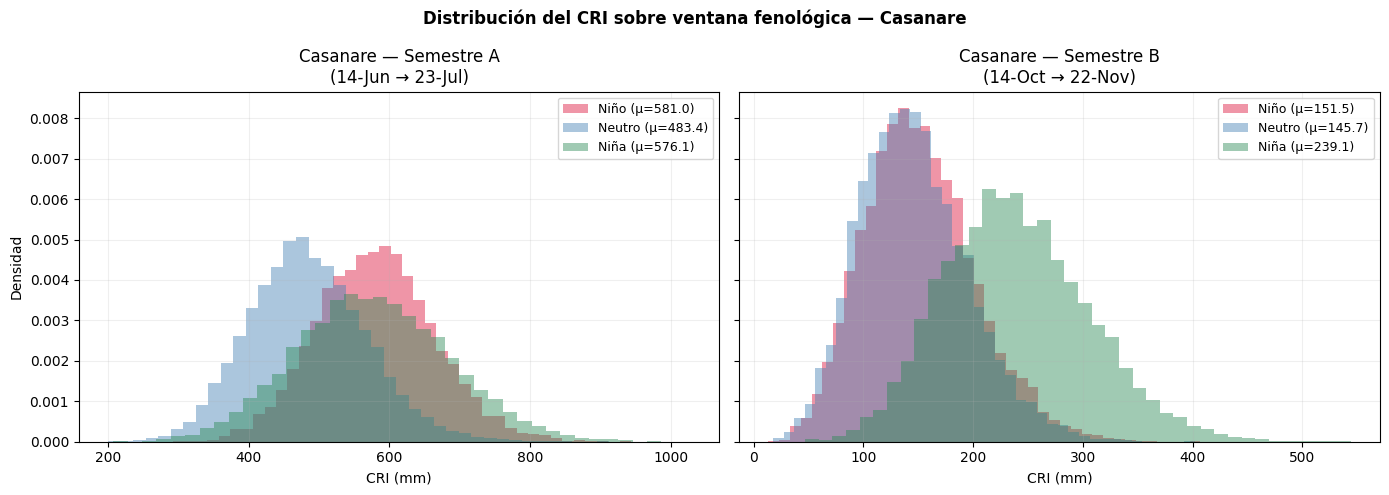

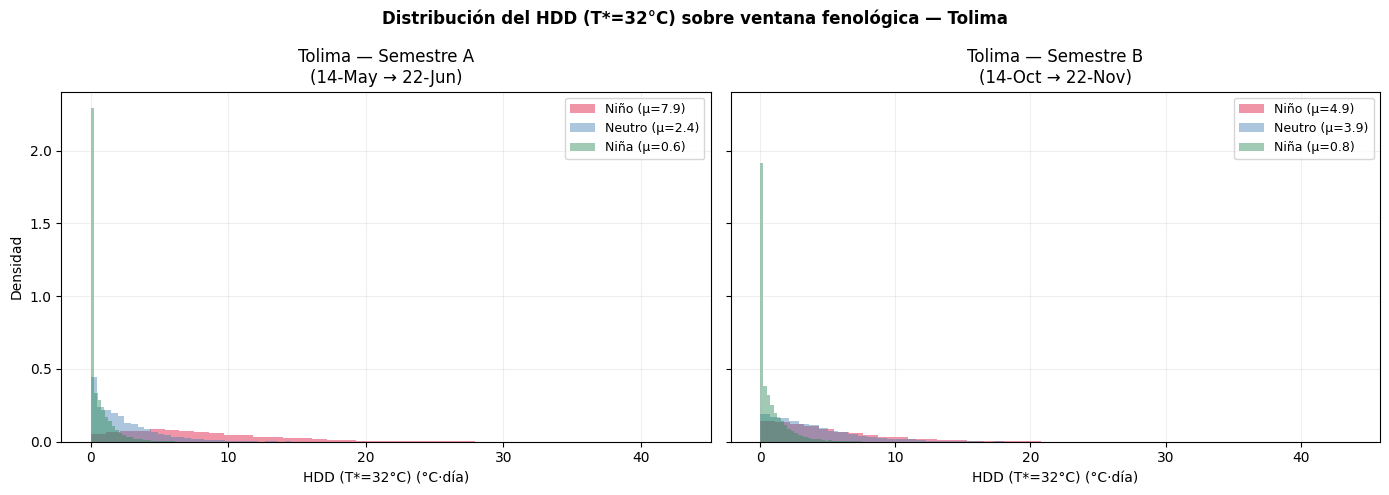

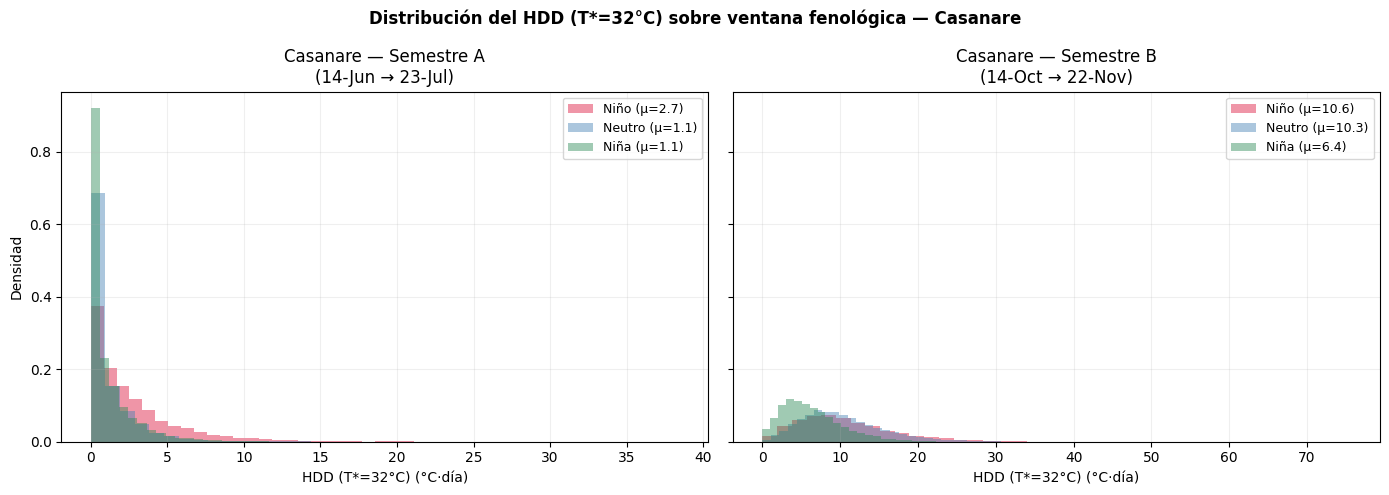

In [18]:
COLORES = {"Niño": "crimson", "Neutro": "steelblue", "Niña": "seagreen"}


def graficar_distribuciones(indices, ventanas_df, variable, titulo_var, unidad):
    """Una figura por dpto con paneles (semestre, fase)."""
    for dpto in ["Tolima", "Casanare"]:
        ventanas_dpto = ventanas_df[ventanas_df["dpto"] == dpto]
        if ventanas_dpto.empty: continue

        sub = indices[indices["dpto"] == dpto]
        semestres = sorted(sub["semestre"].unique())
        n_sem = len(semestres)

        fig, axes = plt.subplots(1, n_sem, figsize=(7 * n_sem, 5), sharey=True)
        if n_sem == 1: axes = [axes]

        for j, sem in enumerate(semestres):
            ax = axes[j]
            for fase in ESCENARIOS:
                vals = sub[(sub["semestre"] == sem) & (sub["fase"] == fase)][variable]
                if vals.empty: continue
                ax.hist(vals, bins=40, alpha=0.45, color=COLORES[fase],
                        label=f"{fase} (μ={vals.mean():.1f})", density=True)

            v_info = ventanas_dpto[ventanas_dpto["semestre"] == sem].iloc[0]
            ax.set_title(f"{dpto} — Semestre {sem}\n"
                         f"({v_info['inicio'].strftime('%d-%b')} → "
                         f"{v_info['fin'].strftime('%d-%b')})")
            ax.set_xlabel(f"{titulo_var} ({unidad})"); ax.legend(fontsize=9)
            ax.grid(alpha=0.2)
        axes[0].set_ylabel("Densidad")
        fig.suptitle(f"Distribución del {titulo_var} sobre ventana fenológica — {dpto}",
                     fontsize=12, fontweight="bold")
        plt.tight_layout()
        plt.show()


graficar_distribuciones(indices, ventanas_df, "CRI", "CRI", "mm")
graficar_distribuciones(indices, ventanas_df, f"HDD_{int(T_STAR_REF)}", f"HDD (T*={int(T_STAR_REF)}°C)", "°C·día")

## 8. Comparación entre escenarios ENSO

El gradiente entre Niño/Neutro/Niña en los índices es lo que viabiliza el contrato. Si las distribuciones son indistinguibles, no hay valor de cobertura.

CRI por fase ENSO:
    dpto semestre   fase   mean    std    p10    p90
Casanare        A Neutro 483.42  83.39 379.36 589.77
Casanare        A   Niña 576.06 109.07 436.84 717.38
Casanare        A   Niño 580.99  83.16 476.78 688.41
Casanare        B Neutro 145.74  49.14  86.47 210.59
Casanare        B   Niña 239.09  66.14 157.46 326.13
Casanare        B   Niño 151.52  50.26  89.78 217.61
  Tolima        A Neutro 154.72  74.51  70.10 252.96
  Tolima        A   Niña 208.52  74.76 115.97 307.53
  Tolima        A   Niño 145.43  93.14  46.71 271.86
  Tolima        B Neutro 135.74  54.56  70.90 209.07
  Tolima        B   Niña 214.40  66.30 131.65 303.37
  Tolima        B   Niño 131.65  63.06  59.00 217.51


C:\Users\danie\AppData\Local\Temp\ipykernel_908\2634628332.py:28: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[ax_i].boxplot(datos, labels=orden, patch_artist=True, showfliers=False)
C:\Users\danie\AppData\Local\Temp\ipykernel_908\2634628332.py:28: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[ax_i].boxplot(datos, labels=orden, patch_artist=True, showfliers=False)


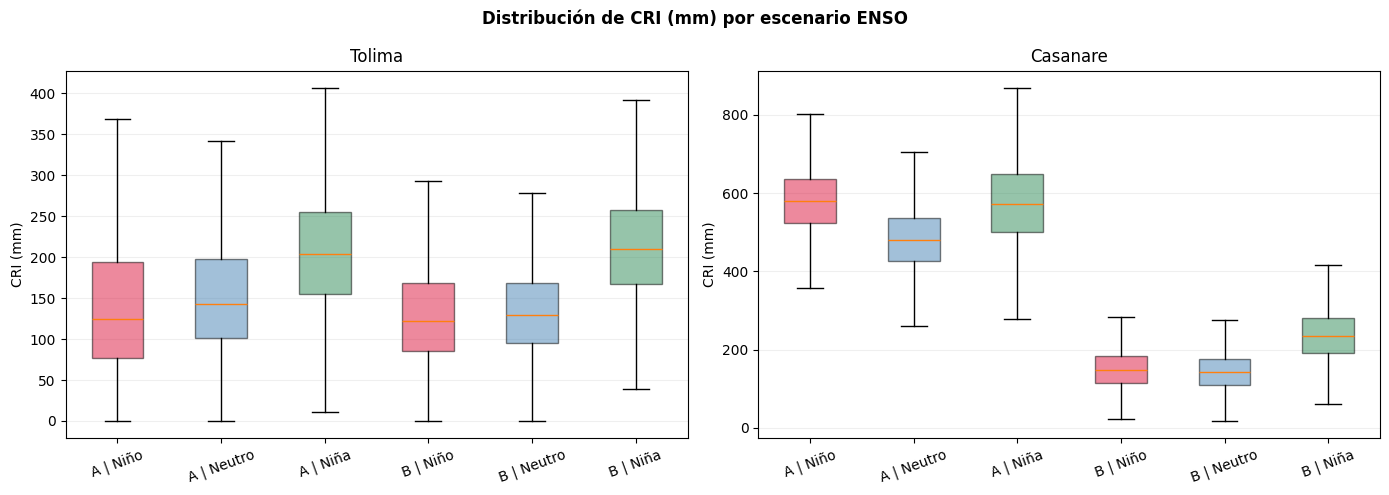

C:\Users\danie\AppData\Local\Temp\ipykernel_908\2634628332.py:28: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[ax_i].boxplot(datos, labels=orden, patch_artist=True, showfliers=False)
C:\Users\danie\AppData\Local\Temp\ipykernel_908\2634628332.py:28: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[ax_i].boxplot(datos, labels=orden, patch_artist=True, showfliers=False)


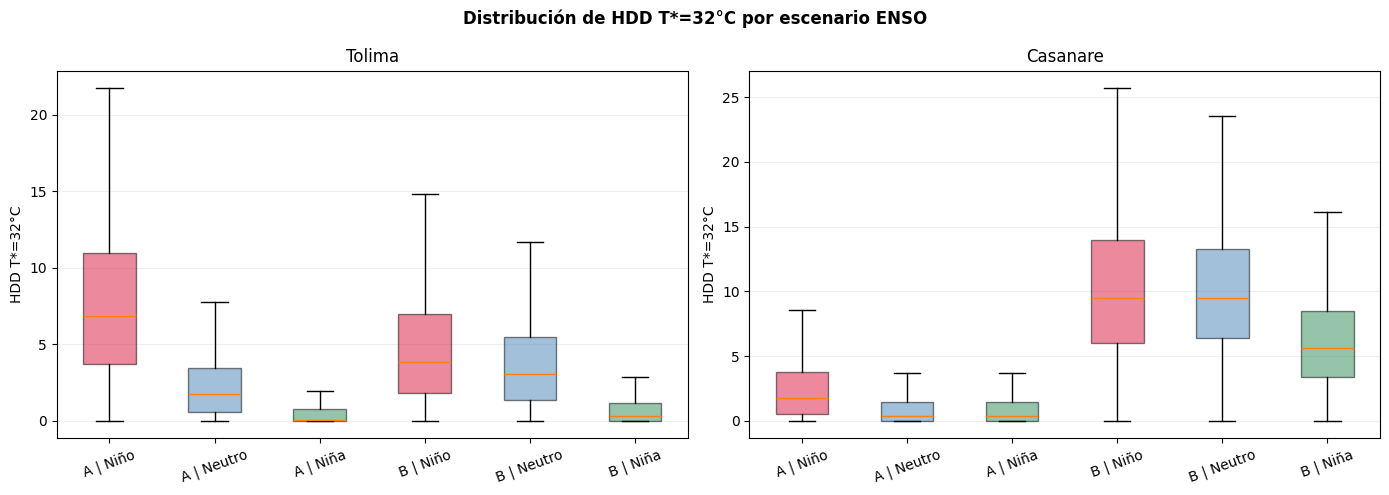

In [19]:
def comparar_fases_enso(indices, variable):
    """Tabla y boxplot del índice por fase ENSO."""
    tabla = (indices.groupby(["dpto", "semestre", "fase"], observed=True)[variable]
                    .agg(["mean", "std", ("p10", lambda x: x.quantile(0.1)),
                          ("p90", lambda x: x.quantile(0.9))])
                    .round(2)
                    .reset_index())
    return tabla


print("CRI por fase ENSO:")
print(comparar_fases_enso(indices, "CRI").to_string(index=False))

# Boxplot comparativo
for variable, titulo in [("CRI", "CRI (mm)"), (f"HDD_{int(T_STAR_REF)}", f"HDD T*={int(T_STAR_REF)}°C")]:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)
    for ax_i, dpto in enumerate(["Tolima", "Casanare"]):
        sub = indices[indices["dpto"] == dpto]
        if sub.empty: continue
        sub = sub.copy()
        sub["grupo"] = sub["semestre"] + " | " + sub["fase"].astype(str)
        orden = []
        for sem in sorted(sub["semestre"].unique()):
            for fase in ESCENARIOS:
                if ((sub["semestre"] == sem) & (sub["fase"] == fase)).any():
                    orden.append(f"{sem} | {fase}")
        datos = [sub[sub["grupo"] == g][variable].values for g in orden]
        bp = axes[ax_i].boxplot(datos, labels=orden, patch_artist=True, showfliers=False)
        for patch, label in zip(bp["boxes"], orden):
            fase = label.split(" | ")[-1]
            patch.set_facecolor(COLORES[fase]); patch.set_alpha(0.5)
        axes[ax_i].set_title(dpto); axes[ax_i].set_ylabel(titulo)
        axes[ax_i].tick_params(axis="x", rotation=20); axes[ax_i].grid(alpha=0.2, axis="y")
    fig.suptitle(f"Distribución de {titulo} por escenario ENSO",
                 fontsize=12, fontweight="bold")
    plt.tight_layout()
    plt.show()

## 9. Exportación

Se exportan a `data/processed/indices.parquet` los índices por trayectoria para uso en el notebook 08 (valoración).

In [20]:
# Categóricas para reducir tamaño
indices_export = indices.copy()
for col in ["dpto", "semestre", "fase"]:
    indices_export[col] = indices_export[col].astype("category")

out_path = OUT_DIR / "indices.parquet"
indices_export.to_parquet(out_path, index=False)
print(f"Índices exportados a: {out_path}  ({out_path.stat().st_size/1e6:.2f} MB)")
print(f"Filas: {len(indices_export):,}  "
      f"({indices_export['path_id'].nunique()} paths × "
      f"{indices_export[['dpto','semestre','fase']].drop_duplicates().shape[0]} combinaciones)")

# También exportar tabla de ventanas + diagnóstico de bias
ventanas_export = ventanas_df.copy()
ventanas_export["inicio"] = ventanas_export["inicio"].dt.strftime("%Y-%m-%d")
ventanas_export["fin"]    = ventanas_export["fin"].dt.strftime("%Y-%m-%d")
ventanas_export.to_csv(OUT_DIR / "ventanas_fenologicas.csv", index=False)

comparativo.to_csv(OUT_DIR / "bias_diagnostico.csv", index=False)
print(f"\nAdicionales:")
print(f"  - ventanas_fenologicas.csv  ({len(ventanas_export)} ventanas)")
print(f"  - bias_diagnostico.csv      ({len(comparativo)} grupos)")

Índices exportados a: ..\data\processed\indices.parquet  (3.73 MB)
Filas: 120,000  (10000 paths × 12 combinaciones)

Adicionales:
  - ventanas_fenologicas.csv  (4 ventanas)
  - bias_diagnostico.csv      (12 grupos)
